In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random

In [2]:
# graph output varies on each run but we can make that static by - fixing the numpy and python random seeds
seed = 0
random.seed(seed)
np.random.seed(seed)

G = nx.Graph()

In [3]:
# adding edges and nodes to our undirected graph
G.add_edge(1,2)

In [4]:
G[1][2]

{}

In [5]:
G.add_edge(1,2,length=7)

In [6]:
G[1][2]

{'length': 7}

In [7]:
G.add_edge(1,2,length=8,weight=20)

In [8]:
G[1][2]

{'length': 8, 'weight': 20}

In [9]:
G.edges(data=True)

EdgeDataView([(1, 2, {'length': 8, 'weight': 20})])

In [10]:
G.add_edge("A","B")
G.add_edge("B","B")
G.add_node("C")

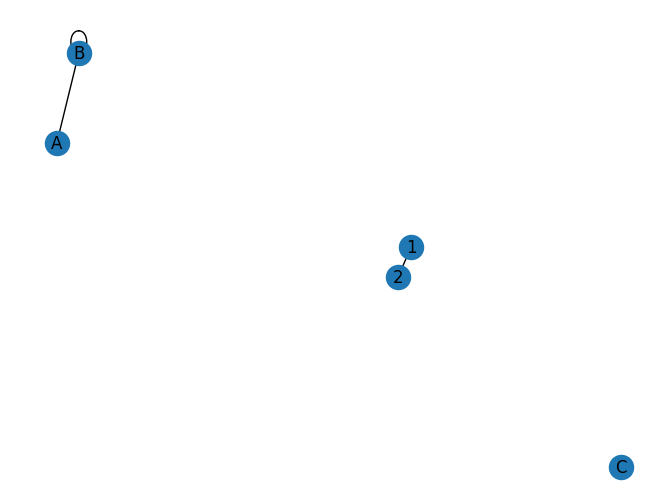

In [11]:
nx.draw_spring(G, with_labels=True)
plt.show()

nx.draw_spring: draws a graph using a force directed spring layout. it places nodes in 2D, so that connected nodes are closer together like they're tied by springs... | 
- intuition:
  - edges = springs pulling nodes together | nodes = charged particles pushing each other apart
  - so, connected npdes are pulled together | unrelated nodes are pushed apart

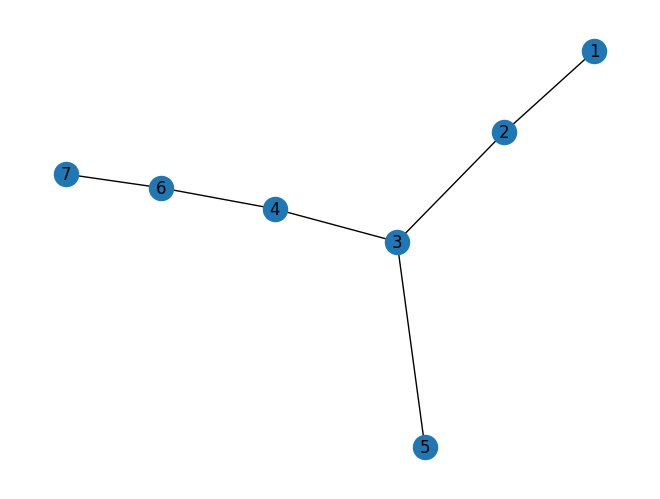

In [12]:
edge_list = [(1,2),(2,3),(3,4),(3,5),(4,6),(6,7)]

G = nx.from_edgelist(edge_list)
nx.draw_spring(G, with_labels=True)

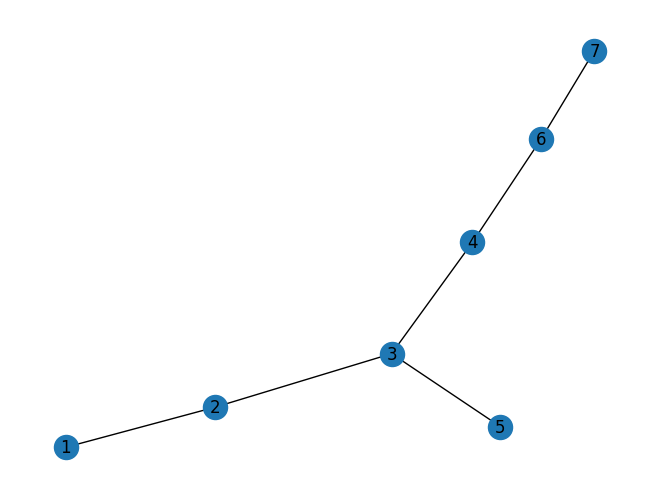

In [13]:
G = nx.Graph()
G.add_edges_from(edge_list)
nx.draw_spring(G, with_labels=True)

- we can represent these graphs in different ways:
  - can use the adjacency matrix
  - fetch the representation as follows

In [14]:
print(nx.adjacency_matrix(G))

<Compressed Sparse Row sparse array of dtype 'int64'
	with 12 stored elements and shape (7, 7)>
  Coords	Values
  (0, 1)	1
  (1, 0)	1
  (1, 2)	1
  (2, 1)	1
  (2, 3)	1
  (2, 4)	1
  (3, 2)	1
  (3, 5)	1
  (4, 2)	1
  (5, 3)	1
  (5, 6)	1
  (6, 5)	1


In [15]:
edge_list

[(1, 2), (2, 3), (3, 4), (3, 5), (4, 6), (6, 7)]

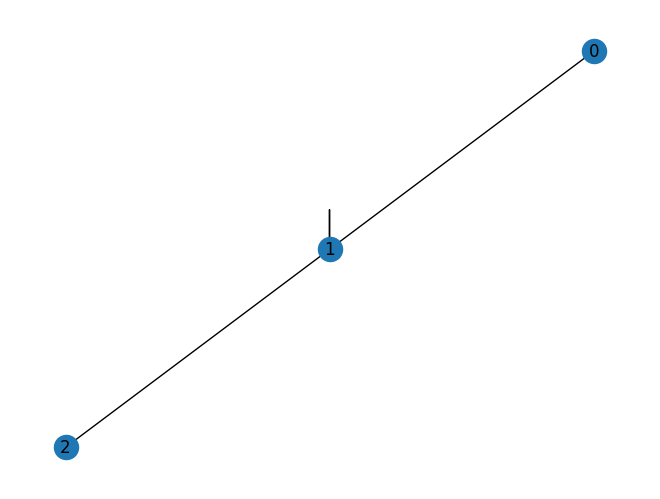

In [17]:
# adjacency matrix with numpy
# creating a numpy array to hold the relationship/connection...where 1 represents a valid connection between nodes

a = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 0, 0]
])

G = nx.from_numpy_array(a)
nx.draw_spring(G, with_labels=True)

can also use nx.draw_circular to draw which:
 - places all nodes evenly on a circle, ignoring structure | idea is that nodes placed at equal angles round a circle edges get drawn afterward | no clustering logic

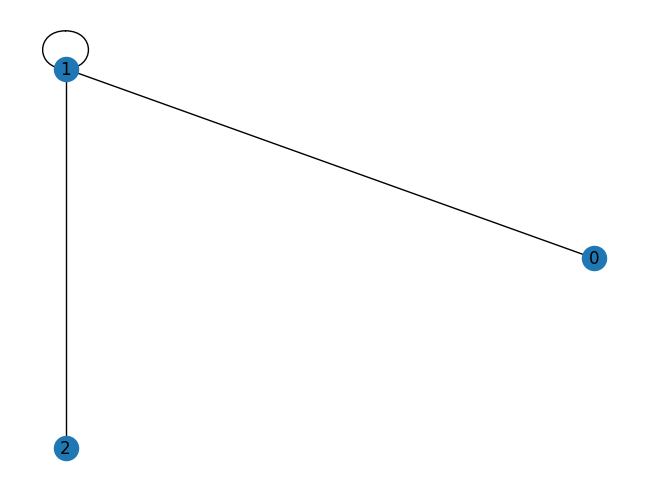

In [18]:
nx.draw_circular(G, with_labels=True)

- other drawing variations:
 - draw_planar: attempts to draw the graph without any edge crossings | only works if the graph is actually planar itself |
 - draw_spectral: uses eigenvectors of the laplacian to position nodes 
 - draw_random: places nodes randomly in space
 - draw_shell: places nodes in concentric circles

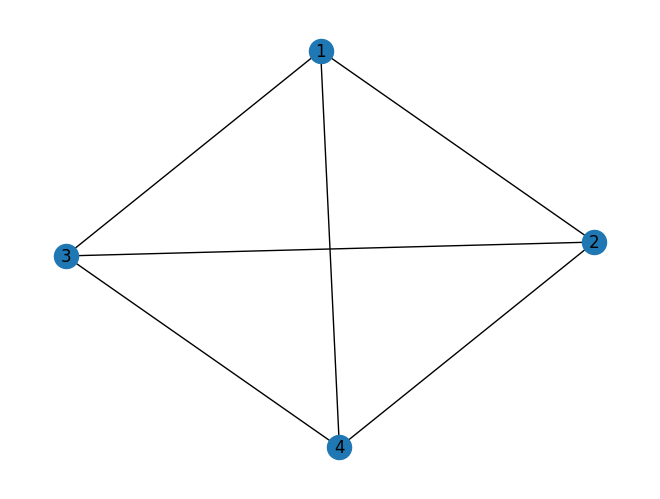

In [19]:
edge_list = [(1,2),(1,3),(1,4),(2,3),(2,4),(3,4)]

G = nx.Graph()
G.add_edges_from(edge_list)

nx.draw_spring(G, with_labels=True)

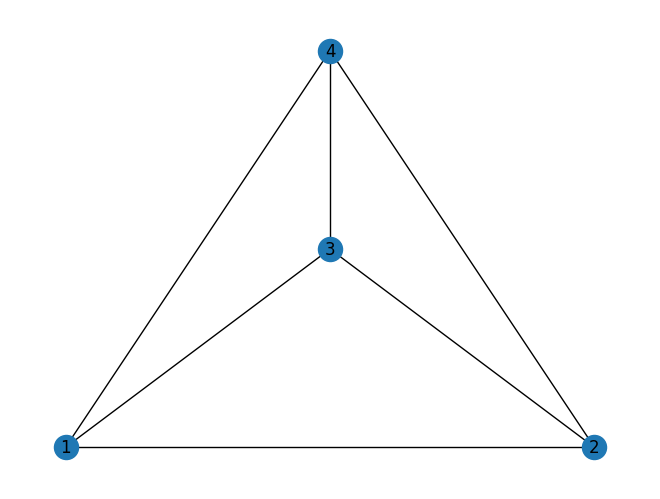

In [20]:
nx.draw_planar(G, with_labels=True)

complete graph:
 - nx.complete_graph: creates a graph where every node is connected to every other node

In [21]:
G = nx.complete_graph(5)

In [22]:
G.edges(data=True)

EdgeDataView([(0, 1, {}), (0, 2, {}), (0, 3, {}), (0, 4, {}), (1, 2, {}), (1, 3, {}), (1, 4, {}), (2, 3, {}), (2, 4, {}), (3, 4, {})])

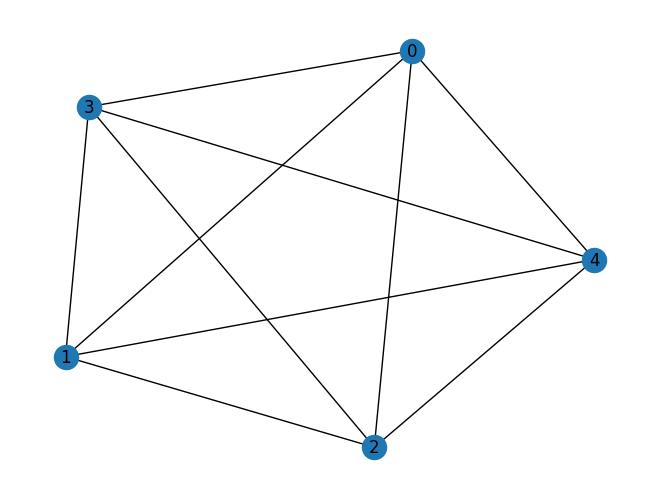

In [23]:
nx.draw_spring(G, with_labels=True)

Get information about a graph:
- extract the degree of a graph

In [24]:
edge_list = [(1,2),(1,3),(1,4),(2,3),(2,4),(3,4)]
G = nx.Graph()
G.add_edges_from(edge_list)

In [25]:
print(dict(G.degree))

{1: 3, 2: 3, 3: 3, 4: 3}


for directed graphs:
 - we have degree in and degree out

In [26]:
edge_list = [(1,2),(2,3),(3,4),(3,5),(4,6),(6,7)]

G = nx.DiGraph()
G.add_edges_from(edge_list)

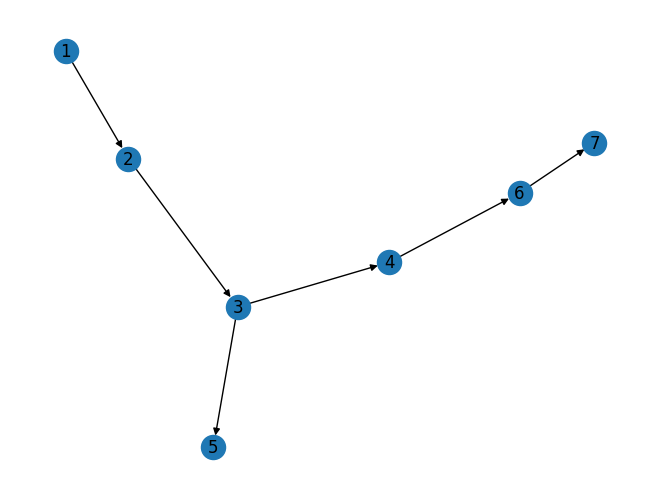

In [27]:
nx.draw_spectral(G, with_labels=True)

In [28]:
print(dict(G.in_degree))

{1: 0, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1}


In [29]:
print(dict(G.out_degree))

{1: 1, 2: 1, 3: 2, 4: 1, 5: 0, 6: 1, 7: 0}


shortest path

In [30]:
edge_list = [(1,2),(2,3),(3,4),(3,5),(4,6),(6,7),(2,8),(8,9),(9,4)]

G = nx.Graph()
G.add_edges_from(edge_list)

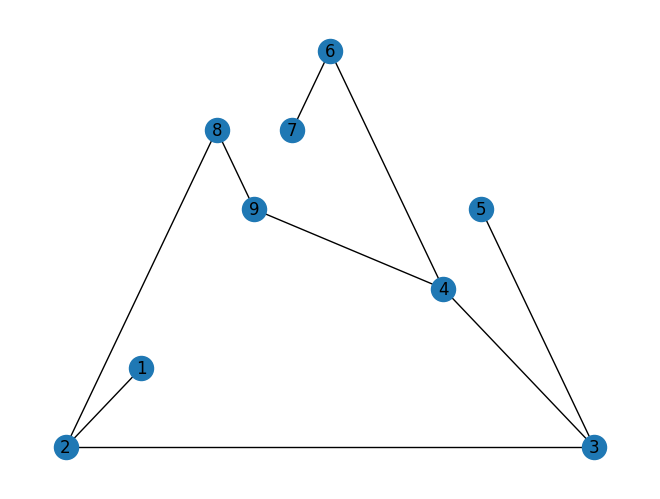

In [31]:
nx.draw_planar(G, with_labels=True)

In [32]:
# computing the shortest path
nx.shortest_path(G, 2, 4)

[2, 3, 4]

updating graphs in networkx:
- suppose we created:
  - G.add_edge(1,2,weight=5,label='road)
  - update: G[1][2]['weight'] = 10
  - can also add new metadata: G[1][2]['capacity'] = 10

- can also update edge data using the add_edge function:
  - G.add_edge(1,2,weight=NEW_WEIGHT)
  

In [33]:
G = nx.Graph()
G.add_edge(1,2,weight=5,label='road')

In [34]:
G.edges(data=True)

EdgeDataView([(1, 2, {'weight': 5, 'label': 'road'})])

In [35]:
G.add_edge(1,2,weight=10)

In [36]:
G.edges(data=True)

EdgeDataView([(1, 2, {'weight': 10, 'label': 'road'})])

updating node metadata:
- removing an edge: G.remove_edge(1,2) | removing multiple edges: G.remove_edges_from([(1,2),(2,3)])
- removing a node: G.remove_node(2)
- updating multiple attributes: G[1][2].update({"weight":50,"label":"highway"})
- checking before updating: G.has_edge(1,2): G[1][2]['weight']=10

Centrality:
 - means which nodes are the most important based on the network structure
 - in networkx, centrality measures score each node according to different notions of importance

In [37]:
nx.degree_centrality(G)

{1: 1.0, 2: 1.0}

betweenness centrality:
- nodes that lie on many shortest paths are important

In [38]:
nx.betweenness_centrality(G)

{1: 0.0, 2: 0.0}

adding nodes and edges:

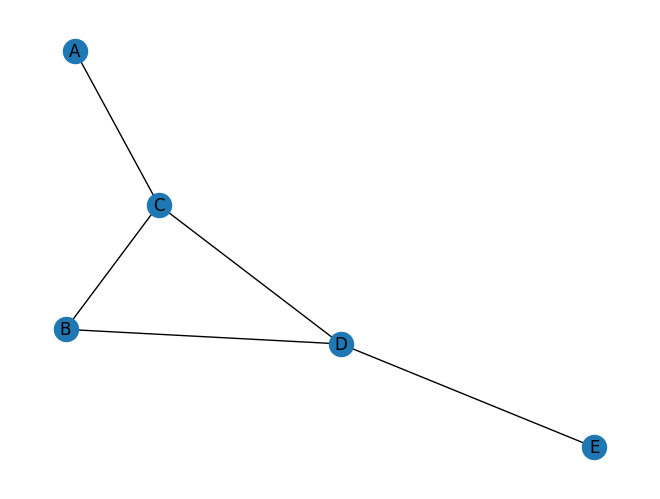

In [39]:
seed = 0
random.seed(seed)
np.random.seed(seed)

G = nx.Graph()
G.add_node("A")
G.add_node("B")
G.add_node("C")
G.add_node("D")
G.add_node("E")

G.add_edge("A", "C")
G.add_edge("B", "C")
G.add_edge("B", "D")
G.add_edge("C", "D")
G.add_edge("D", "E")

nx.draw_spring(G, with_labels=True)

In [40]:
G = nx.Graph()
G.graph["Name"] = "My Graph"

G.add_nodes_from([
    ("A", {"Age":19, "Gender":"F"}),
    ("B", {"Age":18, "Gender":"M"}),
    ("C", {"Age":22, "Gender":"M"}),
    ("D", {"Age":21, "Gender":"M"}),
    ("E", {"Age":20, "Gender":"F"})
])

G.add_edges_from([
    ("A","C",{"weight":1}),
    ("B","C",{"weight":0.5}),
    ("B","D",{"weight":0.6}),
    ("C","D",{"weight":0.8}),
    ("D","E",{"weight":1})
])

In [41]:
# looping through all the nodes
for node in G.nodes:
    print(node)

A
B
C
D
E


In [42]:
# looping through all nodes whilst returning the attributes data
for node in G.nodes(data=True):
    print(node)

('A', {'Age': 19, 'Gender': 'F'})
('B', {'Age': 18, 'Gender': 'M'})
('C', {'Age': 22, 'Gender': 'M'})
('D', {'Age': 21, 'Gender': 'M'})
('E', {'Age': 20, 'Gender': 'F'})


In [43]:
# looping through all edges:
for edge in G.edges(data=True):
    print(edge)

('A', 'C', {'weight': 1})
('B', 'C', {'weight': 0.5})
('B', 'D', {'weight': 0.6})
('C', 'D', {'weight': 0.8})
('D', 'E', {'weight': 1})


In [44]:
# return the total number of nodes and edges in a graph
print(f"#Nodes: {G.number_of_nodes()}")
print(f"#Edges: {G.number_of_edges()}")

#Nodes: 5
#Edges: 5


node degree:

In [46]:
G.degree('A')

1

In [47]:
for node in G.nodes:
    print(f"Degree({node}) = {G.degree(node)}")

Degree(A) = 1
Degree(B) = 2
Degree(C) = 3
Degree(D) = 3
Degree(E) = 1


how to compute the neighbors of a node

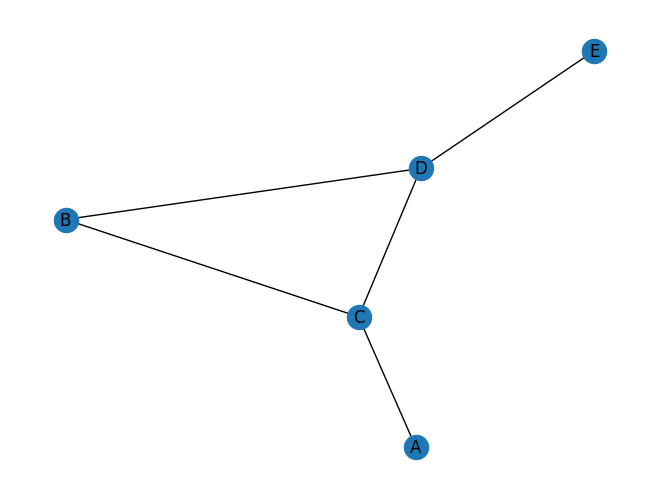

In [48]:
nx.draw_spring(G, with_labels=True)

In [51]:
list(G.neighbors('D'))

['B', 'C', 'E']

neighbors returns only the first direct connections

In [52]:
for node in G.nodes:
    neighbor_list = [n for n in G.neighbors(node)]
    print(f"Neighbor({node}) = {neighbor_list}")

Neighbor(A) = ['C']
Neighbor(B) = ['C', 'D']
Neighbor(C) = ['A', 'B', 'D']
Neighbor(D) = ['B', 'C', 'E']
Neighbor(E) = ['D']


plotting an attributed graph:

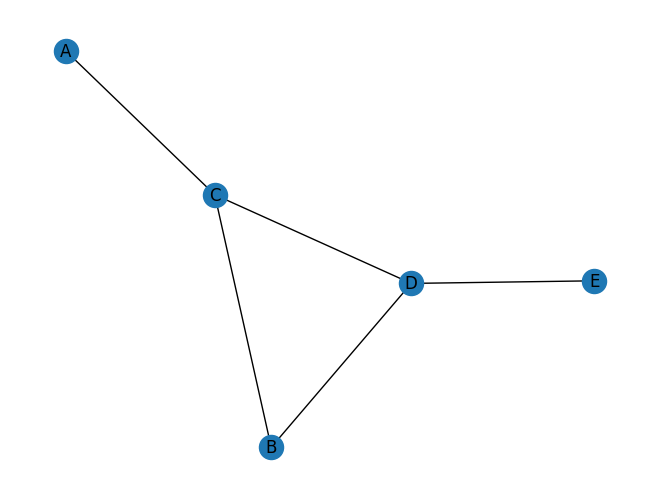

In [55]:
G = nx.Graph()
G.graph["Name"] = "My Graph"

G.add_nodes_from([
    ("A", {"Age":19, "Gender":"F"}),
    ("B", {"Age":18, "Gender":"M"}),
    ("C", {"Age":22, "Gender":"M"}),
    ("D", {"Age":21, "Gender":"M"}),
    ("E", {"Age":20, "Gender":"F"})
])

G.add_edges_from([
    ("A","C",{"weight":1}),
    ("B","C",{"weight":0.5}),
    ("B","D",{"weight":0.6}),
    ("C","D",{"weight":0.8}),
    ("D","E",{"weight":1})
])

nx.draw_spring(G, with_labels=True)

**Graph Traversals:**
- process of visiting every node in the graph 
- 2 main graph traversal algorithms:
  - breadth-first search
  - depth-first search

In [1]:
with open("graph.txt") as f:
    lines = f.readlines()

In [4]:
edgeList = [line.strip().split() for line in lines]
edgeList

[['go', 'a'],
 ['go', 'b'],
 ['go', 'c'],
 ['a', 'd'],
 ['a', 'e'],
 ['a', 'b'],
 ['b', 'f'],
 ['b', 'c'],
 ['c', 'g'],
 ['d', 'h'],
 ['d', 'e'],
 ['e', 'f'],
 ['f', 'i'],
 ['g', 'f'],
 ['h', 'i']]

In [6]:
import networkx as nx 
import matplotlib.pyplot as plt

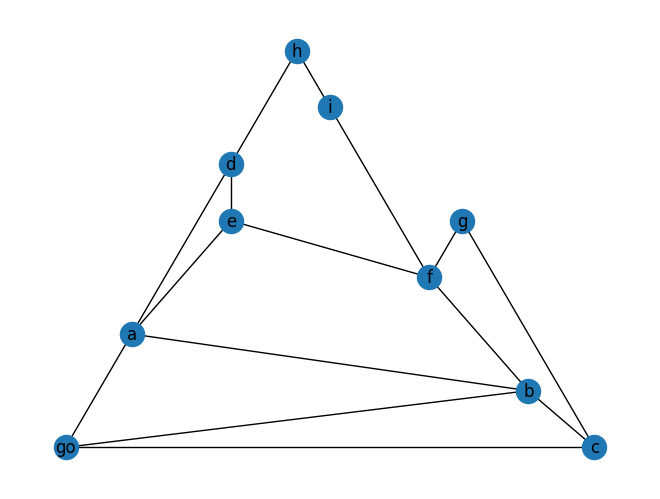

In [7]:
g = nx.Graph()
g.add_edges_from(edgeList)

nx.draw_planar(g, with_labels=True)

In [8]:
bfs = nx.bfs_tree(g, source="go")

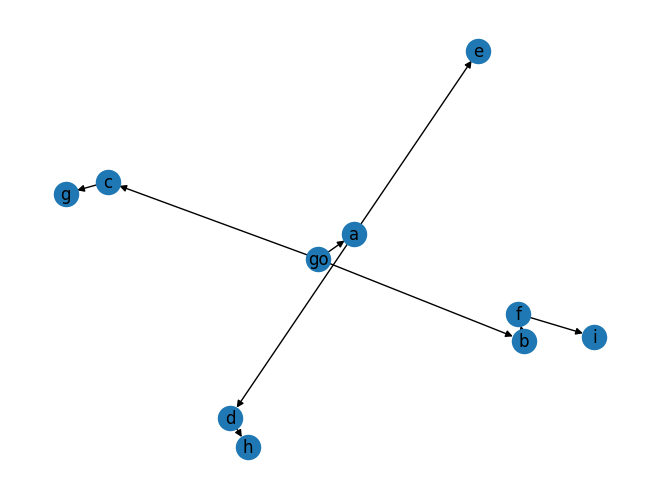

In [10]:
nx.draw(bfs, with_labels=True)